In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")

import warnings; warnings.filterwarnings("ignore")
import polars as pl, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb, mlflow, joblib, os
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

from src.features import FEATURES
from src.evaluation import bootstrap_ci, paired_bootstrap, recall_at_daily_budget, cost_curve

TRAIN_END, VAL_END = 322, 376   # your numbers from Phase 3

In [2]:
feat = pl.read_parquet("../data/processed/features.parquet")
train = feat.filter(pl.col("step") <= TRAIN_END)
val   = feat.filter((pl.col("step") > TRAIN_END) & (pl.col("step") <= VAL_END))
test  = feat.filter(pl.col("step") > VAL_END)

def xy(d):
    return d.select(FEATURES).to_pandas(), d["isFraud"].to_numpy()

X_tr, y_tr = xy(train)
X_va, y_va = xy(val)
X_te, y_te = xy(test)
print(X_tr.shape, X_va.shape, X_te.shape)

(1938484, 15) (415628, 15) (416297, 15)


In [3]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("scamshield")

2026/09/29 12:03:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/29 12:03:49 INFO mlflow.store.db.utils: Updating database tables
2026/09/29 12:03:50 INFO mlflow.tracking.fluent: Experiment with name 'scamshield' does not exist. Creating a new experiment.


<Experiment: artifact_location='/workspaces/ScamShieldProject/notebooks/mlruns/1', creation_time=1790683430978, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790683430978, lifecycle_stage='active', name='scamshield', tags={}, trace_location=None, workspace='default'>

In [4]:
with mlflow.start_run(run_name="logreg_baseline"):
    lr = make_pipeline(FunctionTransformer(np.log1p), StandardScaler(),
                       LogisticRegression(class_weight="balanced", max_iter=1000))
    lr.fit(X_tr, y_tr)
    p_va_lr = lr.predict_proba(X_va)[:, 1]
    score = average_precision_score(y_va, p_va_lr)
    mlflow.log_metric("val_pr_auc", score)
print("Logistic regression, validation PR-AUC:", round(score, 3))

Logistic regression, validation PR-AUC: 0.113


In [5]:
pos, neg = y_tr.sum(), len(y_tr) - y_tr.sum()

with mlflow.start_run(run_name="lgbm_v1"):
    params = dict(n_estimators=1500, learning_rate=0.05, num_leaves=63,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                  scale_pos_weight=neg / pos, verbose=-1)
    lgbm = lgb.LGBMClassifier(**params)
    lgbm.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
             callbacks=[lgb.early_stopping(100, verbose=False)])
    p_va_lgb = lgbm.predict_proba(X_va)[:, 1]
    score = average_precision_score(y_va, p_va_lgb)
    mlflow.log_params(params); mlflow.log_metric("val_pr_auc", score)
print("LightGBM, validation PR-AUC:", round(score, 3), "| trees used:", lgbm.best_iteration_)

LightGBM, validation PR-AUC: 0.822 | trees used: 8


In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators=1500, verbose=-1, subsample_freq=1,
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 255, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 500, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 1, neg / pos, log=True),
    )
    m = lgb.LGBMClassifier(**params).fit(
        X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
        callbacks=[lgb.early_stopping(100, verbose=False)])
    trial.set_user_attr("best_iter", m.best_iteration_)
    return average_precision_score(y_va, m.predict_proba(X_va)[:, 1])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=1800, show_progress_bar=True)
print("Best validation PR-AUC:", round(study.best_value, 3))
print("Best settings:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

Best validation PR-AUC: 0.978
Best settings: {'learning_rate': 0.0237827526476655, 'num_leaves': 146, 'min_child_samples': 112, 'subsample': 0.9999950913016612, 'colsample_bytree': 0.7208848766382325, 'reg_lambda': 0.02987259666332525, 'scale_pos_weight': 9.648331807358348}


In [7]:
best = {**study.best_params,
        "n_estimators": study.best_trial.user_attrs["best_iter"],
        "subsample_freq": 1, "verbose": -1}

with mlflow.start_run(run_name="lgbm_tuned"):
    final = lgb.LGBMClassifier(**best).fit(X_tr, y_tr)
    p_va_raw = final.predict_proba(X_va)[:, 1]
    mlflow.log_params(best)
    mlflow.log_metric("val_pr_auc", average_precision_score(y_va, p_va_raw))
print("Tuned model, validation PR-AUC:", round(average_precision_score(y_va, p_va_raw), 3))

Tuned model, validation PR-AUC: 0.978


In [8]:
from sklearn.model_selection import TimeSeriesSplit

scores = []
for tr_idx, va_idx in TimeSeriesSplit(n_splits=5).split(X_tr):
    m = lgb.LGBMClassifier(**best).fit(X_tr.iloc[tr_idx], y_tr[tr_idx])
    scores.append(average_precision_score(y_tr[va_idx], m.predict_proba(X_tr.iloc[va_idx])[:, 1]))
print("PR-AUC per fold:", np.round(scores, 3))
print(f"Mean {np.mean(scores):.3f} ± {np.std(scores):.3f}")

PR-AUC per fold: [0.958 0.958 0.927 0.996 0.962]
Mean 0.960 ± 0.022


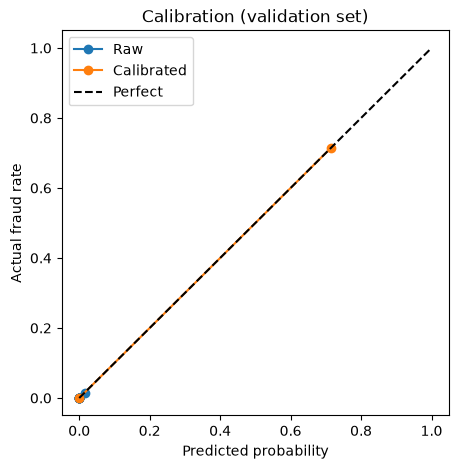

In [9]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

iso = IsotonicRegression(out_of_bounds="clip").fit(p_va_raw, y_va)
p_va_cal = iso.predict(p_va_raw)

plt.figure(figsize=(5, 5))
for name, p in [("Raw", p_va_raw), ("Calibrated", p_va_cal)]:
    frac, mean = calibration_curve(y_va, p, n_bins=10, strategy="quantile")
    plt.plot(mean, frac, marker="o", label=name)
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Actual fraud rate")
plt.title("Calibration (validation set)"); plt.legend()
plt.savefig("../reports/figures/calibration.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
p_te_raw = final.predict_proba(X_te)[:, 1]
p_te     = iso.predict(p_te_raw)
p_te_lr  = lr.predict_proba(X_te)[:, 1]

day_te = test["day"].to_numpy()
amt_te = test["amount"].to_numpy()

rows = []
for name, p in [("Logistic regression", p_te_lr), ("LightGBM", p_te)]:
    mean, ci = bootstrap_ci(y_te, p)
    rows.append({"model": name,
                 "PR-AUC": round(mean, 3),
                 "95% CI": f"{ci[0]:.3f}–{ci[1]:.3f}",
                 "Recall @100/day": round(recall_at_daily_budget(y_te, p, day_te, 100), 3),
                 "Recall @500/day": round(recall_at_daily_budget(y_te, p, day_te, 500), 3)})
results = pd.DataFrame(rows); results

,model,PR-AUC,95% CI,Recall @100/day,Recall @500/day
0,Logistic regression,0.564,0.550–0.580,0.292,0.913
1,LightGBM,0.994,0.992–0.995,0.389,1.000


In [11]:
diff, ci, p_worse = paired_bootstrap(y_te, p_te_lr, p_te)
print(f"LightGBM minus LogReg PR-AUC: {diff:+.3f}")
print(f"95% CI of the difference: {ci[0]:+.3f} to {ci[1]:+.3f}")
print(f"Share of resamples where LightGBM was NOT better: {p_worse:.3f}")

LightGBM minus LogReg PR-AUC: +0.429
95% CI of the difference: +0.414 to +0.444
Share of resamples where LightGBM was NOT better: 0.000


threshold     1.000000e-02
net_saving    5.051337e+09
alerts        4.268000e+03
recall        9.990000e-01
precision     9.410000e-01
Name: 0, dtype: float64


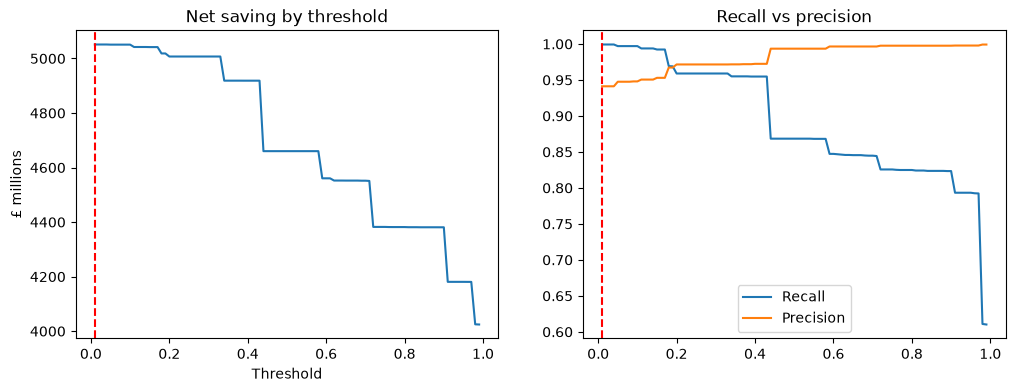

In [12]:
curve = cost_curve(y_te, p_te, amt_te, alert_cost=5, recovery_rate=0.8)
best_row = curve.loc[curve["net_saving"].idxmax()]
T_BEST = float(best_row["threshold"])
print(best_row.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(curve["threshold"], curve["net_saving"] / 1e6)
ax[0].axvline(T_BEST, ls="--", color="red")
ax[0].set_title("Net saving by threshold"); ax[0].set_xlabel("Threshold"); ax[0].set_ylabel("£ millions")
ax[1].plot(curve["threshold"], curve["recall"], label="Recall")
ax[1].plot(curve["threshold"], curve["precision"], label="Precision")
ax[1].axvline(T_BEST, ls="--", color="red"); ax[1].legend(); ax[1].set_title("Recall vs precision")
plt.savefig("../reports/figures/cost_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
for cost in [1, 5, 20, 50]:
    c = cost_curve(y_te, p_te, amt_te, alert_cost=cost)
    r = c.loc[c["net_saving"].idxmax()]
    print(f"Alert cost £{cost:>2}: best threshold {r.threshold:.2f}, alerts {r.alerts:,}, recall {r.recall:.2f}")

Alert cost £ 1: best threshold 0.01, alerts 4,268.0, recall 1.00
Alert cost £ 5: best threshold 0.01, alerts 4,268.0, recall 1.00
Alert cost £20: best threshold 0.01, alerts 4,268.0, recall 1.00
Alert cost £50: best threshold 0.01, alerts 4,268.0, recall 1.00


In [14]:
te = test.to_pandas()
te["score"] = p_te
te["caught"] = te["score"] >= T_BEST
fraud_rows = te[te["isFraud"] == 1]
print("Frauds caught:", fraud_rows["caught"].sum(), "| missed:", (~fraud_rows["caught"]).sum())
fraud_rows.groupby("caught")[FEATURES + ["amount"]].median().T

Frauds caught: 4017 | missed: 3


caught,False,True
is_transfer,1.000000e+00,0.000000
log_amount,1.580561e+01,13.037633
oldbalanceOrg,1.731626e+07,459378.910000
amt_to_bal,4.225079e-01,0.999998
orig_zero_bal,0.000000e+00,0.000000
drains_account,0.000000e+00,1.000000
is_round,0.000000e+00,0.000000
hour,1.700000e+01,11.000000
is_night,0.000000e+00,0.000000
dest_prior_txn,0.000000e+00,0.000000


In [15]:
from sklearn.ensemble import IsolationForest

iforest = IsolationForest(n_estimators=200, random_state=0, n_jobs=-1)
iforest.fit(X_tr[y_tr == 0].sample(200_000, random_state=0))

X_tr2, X_va2, X_te2 = X_tr.copy(), X_va.copy(), X_te.copy()
for X in (X_tr2, X_va2, X_te2):
    X["anomaly_score"] = -iforest.score_samples(X[FEATURES])

m2 = lgb.LGBMClassifier(**best).fit(X_tr2, y_tr)
iso2 = IsotonicRegression(out_of_bounds="clip").fit(m2.predict_proba(X_va2)[:, 1], y_va)
p_te2 = iso2.predict(m2.predict_proba(X_te2)[:, 1])

diff, ci, _ = paired_bootstrap(y_te, p_te, p_te2)
print(f"Adding anomaly score changes PR-AUC by {diff:+.3f} (95% CI {ci[0]:+.3f} to {ci[1]:+.3f})")

Adding anomaly score changes PR-AUC by -0.014 (95% CI -0.017 to -0.012)


In [16]:
os.makedirs("../models", exist_ok=True)
joblib.dump({"model": final, "calibrator": iso, "features": FEATURES,
             "threshold": T_BEST, "logreg": lr}, "../models/scamshield.joblib")

out = te[["step", "day", "type", "amount", "isFraud", *FEATURES]].copy()
out["score"] = p_te
out["score_lr"] = p_te_lr
out.to_parquet("../data/processed/test_scored.parquet")
print("Saved model and scored test set. Threshold =", round(T_BEST, 2))

Saved model and scored test set. Threshold = 0.01


In [17]:
from sklearn.metrics import precision_score, recall_score

rule = te["drains_account"].to_numpy()
alert = (p_te >= T_BEST).astype(int)

print("RULE: 'flag if the payment empties the account'")
print(f"  precision {precision_score(y_te, rule):.3f} | recall {recall_score(y_te, rule):.3f} | alerts {rule.sum():,}")
print("LIGHTGBM at chosen threshold")
print(f"  precision {precision_score(y_te, alert):.3f} | recall {recall_score(y_te, alert):.3f} | alerts {alert.sum():,}")

RULE: 'flag if the payment empties the account'
  precision 0.021 | recall 0.972 | alerts 186,801
LIGHTGBM at chosen threshold
  precision 0.941 | recall 0.999 | alerts 4,268


In [18]:
drop = ["drains_account", "amt_to_bal", "oldbalanceOrg", "orig_zero_bal"]
feats_ab = [f for f in FEATURES if f not in drop]

m_ab = lgb.LGBMClassifier(**best).fit(X_tr[feats_ab], y_tr)
p_ab = m_ab.predict_proba(X_te[feats_ab])[:, 1]
print("PR-AUC without balance features:", round(average_precision_score(y_te, p_ab), 3))

PR-AUC without balance features: 0.449


In [19]:
fraud_per_day = te.groupby("day")["isFraud"].sum()
for b in [100, 500]:
    ceiling = np.minimum(fraud_per_day, b).sum() / fraud_per_day.sum()
    print(f"Budget {b}/day: best possible recall = {ceiling:.3f}")

Budget 100/day: best possible recall = 0.391
Budget 500/day: best possible recall = 1.000


In [ ]:
thr = np.concatenate([np.logspace(-4, -2, 20), np.linspace(0.01, 0.99, 99)])
fine = cost_curve(y_te, p_te, amt_te, alert_cost=5, recovery_rate=0.8, thresholds=thr)
best_fine = fine.loc[fine["net_saving"].idxmax()]
print(best_fine.round(4))

threshold     1.000000e-04
net_saving    5.051337e+09
alerts        4.268000e+03
recall        9.993000e-01
precision     9.412000e-01
Name: 0, dtype: float64


: 

- **Operational:** with 100 alerts/day the model caught 38.9% of fraud against a maximum possible of 39.1%, i.e. 99.5% of what was achievable under that budget. With 500 alerts/day it caught all fraud.
- **Model vs simple rule:** flagging every payment that empties the account catches 97.2% of fraud but raises 186,801 alerts at 2.1% precision. LightGBM catches 99.9% with 4,268 alerts at 94.1% precision: ~44x fewer alerts and ~45x higher precision. Emptying the account is a necessary signal but far from sufficient.
- **Ablation:** removing the balance features drops PR-AUC from 0.994 to 0.449. The model depends heavily on balance patterns, which reflects how simply PaySim generates fraud. The remaining features (receiver history, timing, amount) still perform far above random (~0.01). Real-world fraud would be harder to detect.
- **Threshold:** isotonic calibration produces stepped scores, so any threshold between 0.0001 and 0.01 gives the same 4,268 alerts; I use 0.01. Because PaySim fraud amounts are far larger than alert costs, the optimum doesn't move with alert cost, and absolute £ savings are not realistic figures.